In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Lets load The boston House Pricing dataset

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
caf = fetch_california_housing()

In [4]:
type(caf)

sklearn.utils._bunch.Bunch

In [5]:
caf.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
## lest check the description of the dataset
print(caf.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [7]:
print(caf.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [8]:
print(caf.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [9]:
print(caf.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Preparing The Dataset

In [10]:
dataset = pd.DataFrame(caf.data, columns=caf.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
dataset['Price'] = caf.target

In [12]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
## summarizing the stats of the data

In [15]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [16]:
# check the missing values
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [17]:
# eda
# corr
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [18]:
import seaborn as sns
sns.pairplot(dataset)

In [19]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [20]:
plt.scatter(dataset['Price'], dataset['MedInc'])
plt.xlabel('Price')
plt.ylabel('MedInc')

Text(0, 0.5, 'MedInc')

In [21]:
plt.scatter(dataset['Price'], dataset['HouseAge'])
plt.xlabel('Price')
plt.ylabel('HouseAge')

Text(0, 0.5, 'HouseAge')

In [22]:
plt.scatter(dataset['Price'], dataset['AveRooms'])
plt.xlabel('Price')
plt.ylabel('AveRooms')

Text(0, 0.5, 'AveRooms')

In [23]:
import seaborn as sns
sns.regplot(x='MedInc', y='Price', data=dataset)


<Axes: xlabel='MedInc', ylabel='Price'>

In [24]:
sns.regplot(x='Longitude', y='Price', data=dataset)

<Axes: xlabel='Longitude', ylabel='Price'>

In [25]:
sns.regplot(x='Latitude', y='Price', data=dataset)

<Axes: xlabel='Latitude', ylabel='Price'>

In [26]:
sns.regplot(x='Price', y='Population', data=dataset)

<Axes: xlabel='Price', ylabel='Population'>

In [27]:
# independent and dependent

dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [28]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]


In [29]:
x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [30]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

In [31]:
# Train :  Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.4, random_state= 42)


In [32]:
x_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
9012,5.8735,35.0,5.811639,1.056662,1521.0,2.329250,34.11,-118.63
2769,1.4688,8.0,10.000000,1.916667,63.0,2.625000,33.32,-115.98
1953,2.1603,28.0,4.808173,0.995460,2008.0,2.279228,38.74,-120.78
16897,4.7404,43.0,5.855140,1.009346,967.0,2.259346,37.58,-122.37
17866,3.2617,10.0,3.929142,1.051896,2032.0,2.027944,37.45,-121.92
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [33]:
x_test

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93
...,...,...,...,...,...,...,...,...
10924,3.7500,36.0,5.202105,1.048421,2594.0,5.461053,33.73,-117.88
9976,5.3698,20.0,5.340206,1.041237,589.0,3.036082,38.60,-122.47
5066,1.1645,44.0,5.151943,1.151943,1159.0,4.095406,33.99,-118.30
6840,2.0250,43.0,4.303279,1.032787,820.0,3.360656,34.07,-118.12


In [34]:
# standardize The Dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [35]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [36]:
import pickle 
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [37]:
x_test

array([[-1.15606529, -0.28256859, -0.5051663 , ...,  0.05625153,
         0.187896  ,  0.28934293],
       [-0.70725347,  0.11523618, -0.15975814, ..., -0.03445918,
        -0.24247333,  0.065215  ],
       [-0.20633281,  1.86557714, -0.59284344, ..., -0.13439662,
         1.00185536, -1.41900994],
       ...,
       [-1.42885799,  1.22908952, -0.11386592, ...,  0.07276073,
        -0.78043498,  0.64296699],
       [-0.97455547,  1.14952857, -0.45987822, ...,  0.01710995,
        -0.74301156,  0.73261816],
       [-0.55119092,  0.91084571, -0.13932736, ...,  0.0281061 ,
        -0.82253632,  0.67285071]])

In [ ]:
x_train

array([[ 1.05726701,  0.51304094,  0.15510086, ..., -0.06100982,
        -0.72429985,  0.47860651],
       [-1.26820225, -1.63510479,  1.8627534 , ..., -0.03860938,
        -1.09385611,  1.79847097],
       [-0.90312359, -0.04388573, -0.25402605, ..., -0.0647985 ,
         1.44158054, -0.59222692],
       ...,
       [-0.49443611,  0.59260189, -0.58894466, ...,  0.01494471,
        -0.76172327,  0.60312203],
       [ 0.97580405, -1.07817812,  0.39308755, ...,  0.00334289,
         0.89894096, -1.17994015],
       [-0.683918  ,  1.86557714, -0.82710689, ..., -0.07771481,
         0.98782158, -1.4090487 ]])

In [ ]:
# model training
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


In [ ]:
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
print(lr.coef_)

[ 0.85091974  0.11946588 -0.31419818  0.3617823  -0.0014557  -0.04243573
 -0.89446846 -0.87095145]


In [ ]:
print(lr.intercept_)

2.0633966957364307


In [ ]:
# on which parameter the model has been trained
lr.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [ ]:
lr.score(x_train, y_train)

0.612130026035787

In [ ]:
lr.score(x_test, y_test)

0.5939400468776981

In [ ]:
# prediction with test data
lr_pred = lr.predict(x_test)

##ASSUMPTIONS

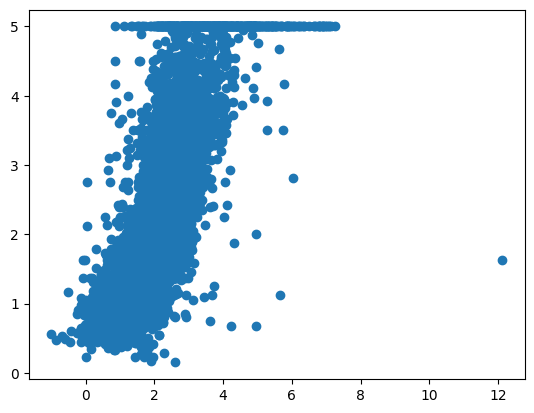

In [ ]:
# plot a scatter plot for the prediction
plt.scatter(lr_pred, y_test)

In [ ]:
residuals = y_test-lr_pred

In [ ]:
residuals

,Price
20046,-0.244073
3024,-1.308203
15663,2.284384
20484,-0.647081
9814,0.179885
...,...
10924,-0.420198
9976,0.392035
5066,-0.228711
6840,0.666006


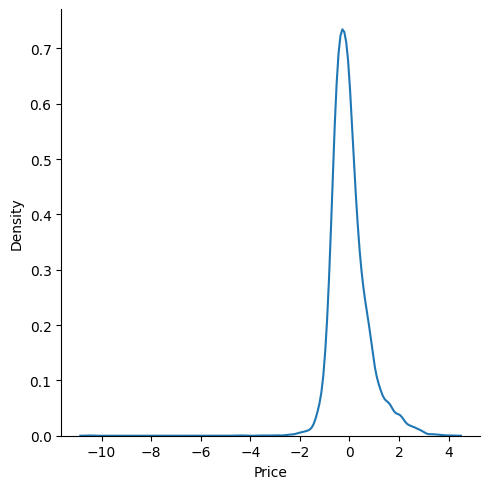

In [ ]:
# ploting this residuals
sns.displot(residuals, kind='kde')

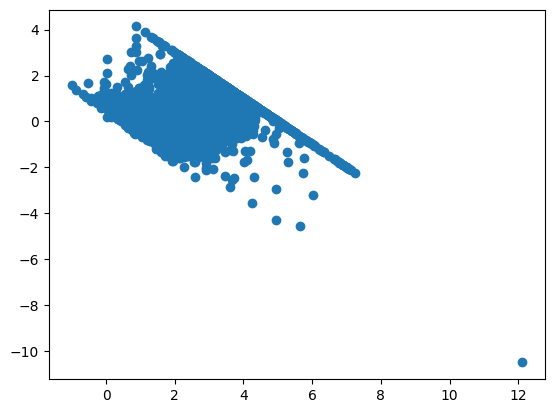

In [ ]:
# scatter plot with respect to prediction and residuals
plt.scatter(lr_pred, residuals)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, lr_pred))
print(mean_squared_error(y_test, lr_pred))
print(np.sqrt(mean_squared_error(y_test, lr_pred)))

0.533686487452728
0.5435945247974568
0.7372886305901216


In [ ]:
# R square and adjusted R square
#SSR = SUM OF SQUARE RESIDUALS AND SST = SUM OF SQUARE TOTAL
# r^2 = 1-SSR/SST

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test, lr_pred)
print(score)

0.5939400468776981


Adjusted R2 = 1 - [(1-R2) * (n-1)/(n-k-1)]
R2 : r2 OF THE MODEL N: THE NUMBER OF OBSERVATIONS K : tHE NUMBER OF PREDICTOR Variables

In [ ]:
# display adjusted r-square

1 - (1-score) *(len(y_test)-1) / (len(y_test)- x_test.shape[1]-1)

0.5935461485358794

# New Data Prediction

In [ ]:
caf.data[0].shape

(8,)

In [ ]:
caf.data[0].reshape(1,-1)

array([[   8.3252    ,   41.        ,    6.98412698,    1.02380952,
         322.        ,    2.55555556,   37.88      , -122.23      ]])

In [ ]:
scaler.transform(caf.data[0].reshape(1,-1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.35164642,  0.99040666,  0.6331405 , -0.1655952 , -0.98469137,
        -0.04386917,  1.03927878, -1.31441691]])

In [ ]:
lr.predict(scaler.transform(caf.data[0].reshape(1,-1)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.14242412])

In [ ]:
lr_pred[0]

np.float64(0.7210726093507143)

Pickling The Model File for Development

In [ ]:
import pickle

In [ ]:
pickle.dump(lr, open('regmodel.pkl','wb'))

In [ ]:
pickled_model = pickle.load(open('regmodel.pkl', 'rb'))

In [ ]:
# Prediction
pickled_model.predict(scaler.transform(caf.data[0].reshape(1,-1)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4.14242412])